In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
import operator
import os

load_dotenv()


True

In [13]:
llm = ChatOpenAI()

In [14]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState) -> dict:
    
    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)
    
    # response store in state
    return {'messages': [response]}

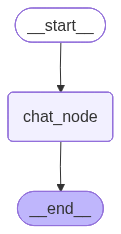

In [16]:
# Checkpointer
checkpointer = MemorySaver()


# Graph
graph = StateGraph(ChatState)


# Nodes
graph.add_node('chat_node', chat_node)


# Edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [17]:
initial_state = {
    'messages': [HumanMessage(content="What is the current status of FIFA World Cup 2026?")]
}

output = workflow.invoke(initial_state)['messages'][-1]
print(output.content)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [18]:
thread_id = '1'


while True:
    
    user_message = input('Type here: ')
    
    print(f'User: {user_message}')
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {
        'configurable': {
            'thread_id': thread_id
        }
    }
    
    response = workflow.invoke({
        'messages': [HumanMessage(content=user_message)]
    }, config=config)
    
    print(f'Assistant: {response["messages"][-1].content}')
    
    

User: Hi my name is Aneesh
Assistant: Hello Aneesh, nice to meet you! How can I assist you today?
User: What is my name?
Assistant: Your name is Aneesh.
User: What is the current status of Football world cup after round of 32 round
Assistant: As of now, there is no round of 32 in the FIFA World Cup. The tournament format consists of a group stage followed by a knockout stage (round of 16, quarter-finals, semi-finals, and the final). The most recent FIFA World Cup was held in 2018 in Russia, and France emerged as the champions. The next FIFA World Cup will be held in Qatar in 2022.
User: you know nothing bye
Assistant: I'm sorry if I couldn't provide the information you were looking for. If you have any other questions in the future, feel free to ask. Goodbye!
User: exit


In [19]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi my name is Aneesh', additional_kwargs={}, response_metadata={}, id='5f6ed30c-db8f-428a-bf44-20eb6fe96c1a'), AIMessage(content='Hello Aneesh, nice to meet you! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 14, 'total_tokens': 31, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Dxojz63IlBdvITRuIs0KrNb3t5jet', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f2bf2-f47d-7b82-9590-e83966f4fca7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 17, 'total_tokens': 31, 'input_token_details': {'aud